In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [2]:
df = pd.read_csv("../data/raw/titanic.csv")

print("Shape:", df.shape)
df.head()

Shape: (899, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 899 entries, 0 to 898
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  899 non-null    int64  
 1   Survived     899 non-null    int64  
 2   Pclass       899 non-null    int64  
 3   Name         899 non-null    object 
 4   Sex          899 non-null    object 
 5   Age          722 non-null    float64
 6   SibSp        899 non-null    int64  
 7   Parch        899 non-null    int64  
 8   Ticket       899 non-null    object 
 9   Fare         899 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     897 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 84.4+ KB


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,899.000000,899.000000,899.000000,722.000000,899.000000,899.000000,899.000000
mean,449.959956,0.380423,2.314794,29.724612,0.518354,0.378198,31.986595
std,259.594708,0.485761,0.834870,14.447692,1.098920,0.803259,49.524918
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,225.500000,0.000000,2.000000,21.000000,0.000000,0.000000,7.895800
50%,450.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,674.500000,1.000000,3.000000,38.000000,1.000000,0.000000,30.847900
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          695
Embarked         2
dtype: int64

In [6]:
(df.isna().sum() / len(df)) * 100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.688543
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.308120
Embarked        0.222469
dtype: float64

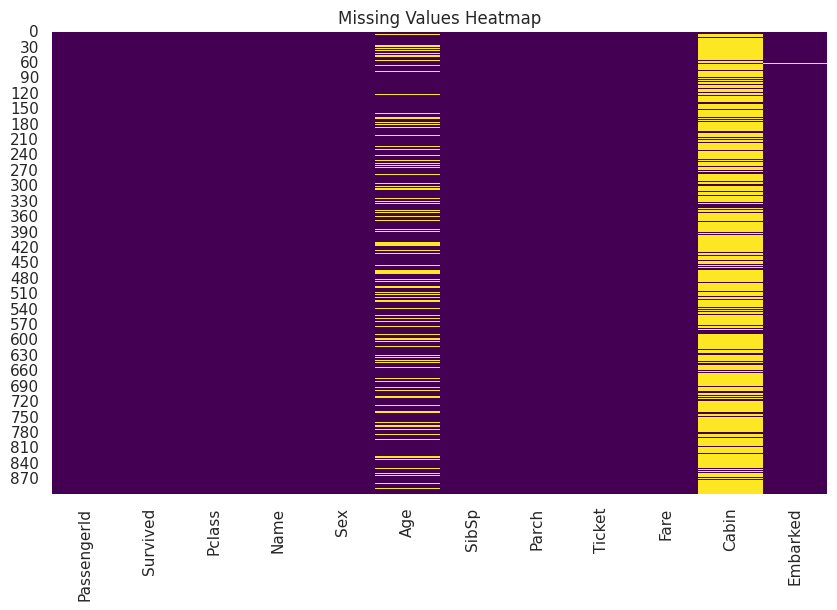

In [7]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isna(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

In [8]:
df.duplicated().sum()

8

In [9]:
num_cols = df.select_dtypes(include=np.number).columns
num_cols

Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

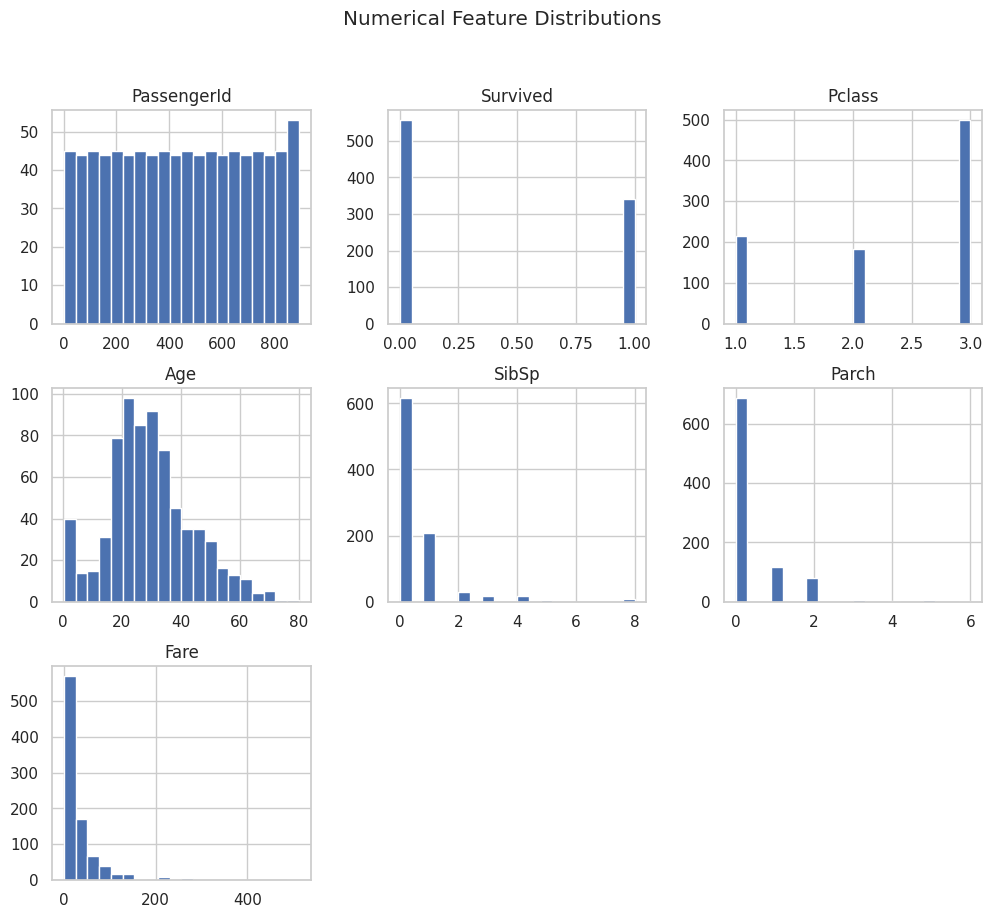

In [10]:
df[num_cols].hist(figsize=(12,10), bins=20)
plt.suptitle("Numerical Feature Distributions")
plt.show()

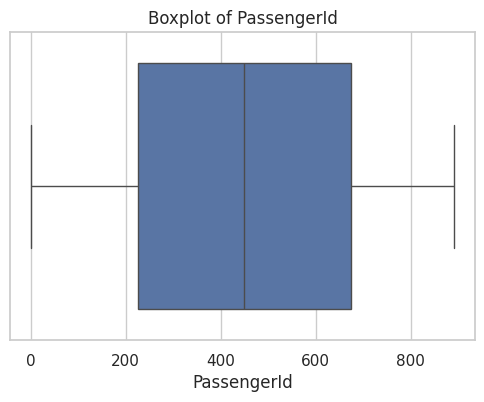

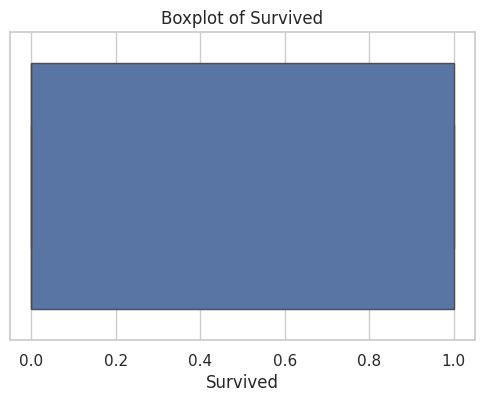

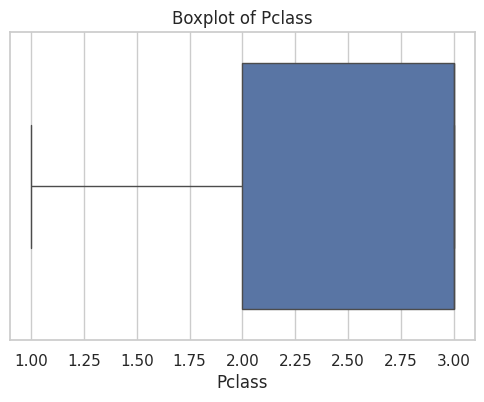

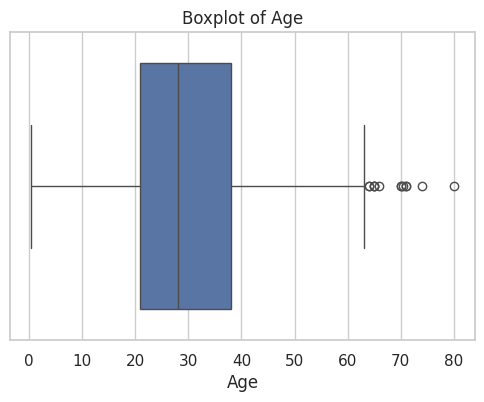

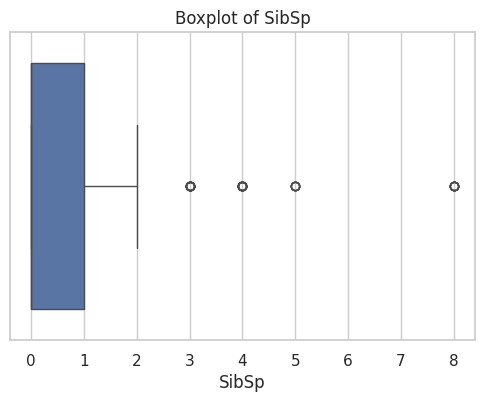

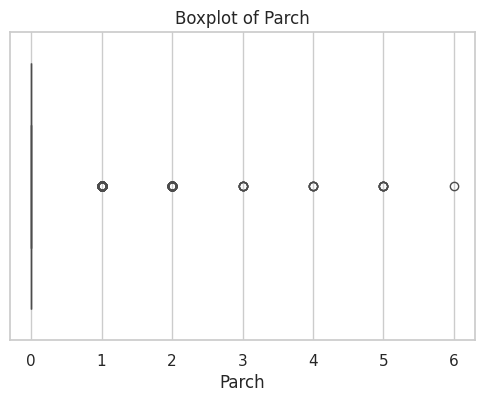

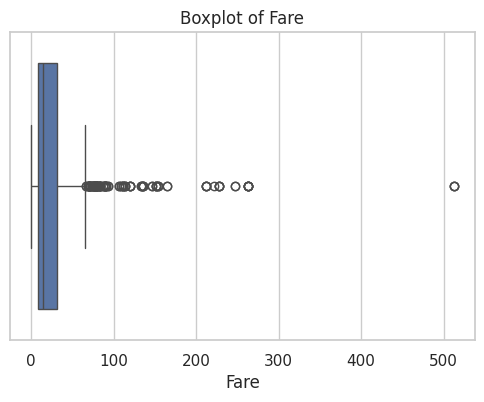

In [11]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [12]:
cat_cols = df.select_dtypes(include='object').columns
cat_cols

Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')

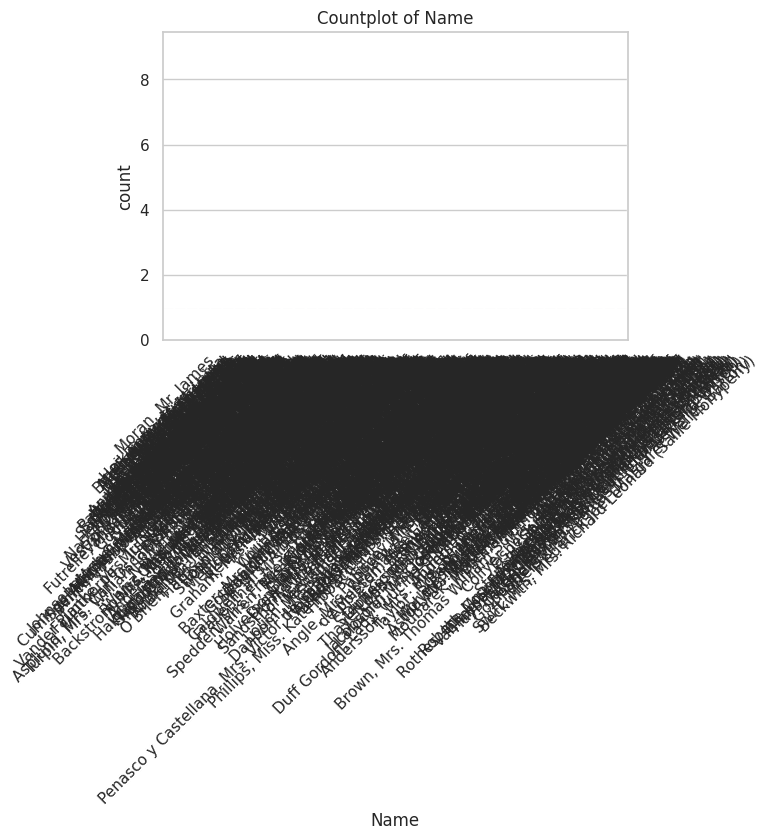

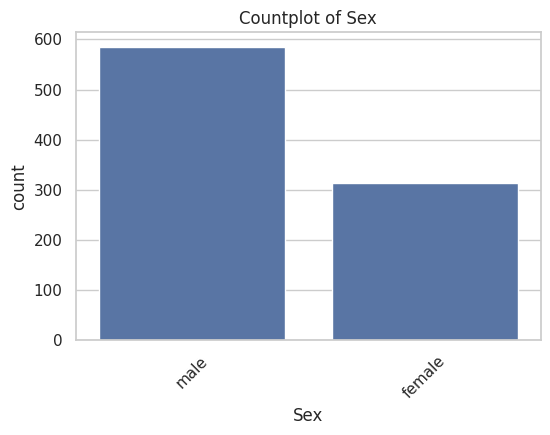

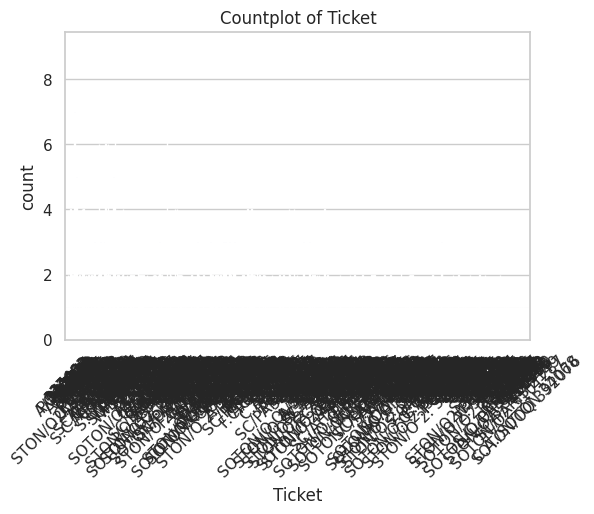

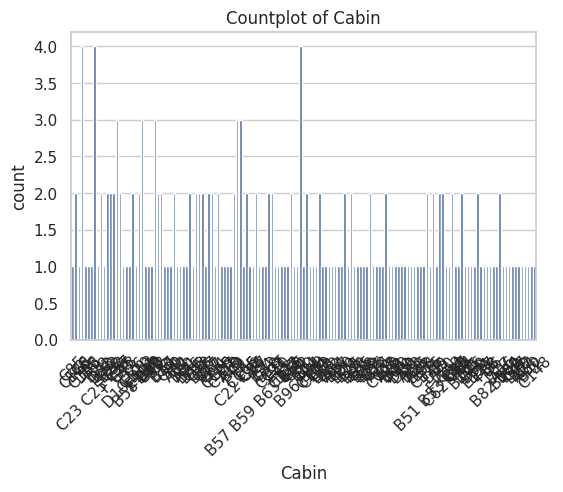

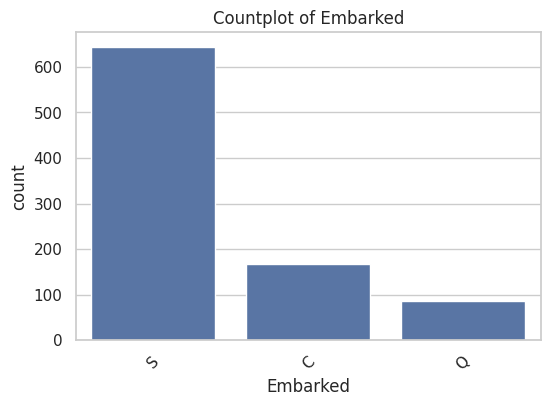

In [13]:
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=df[col])
    plt.title(f"Countplot of {col}")
    plt.xticks(rotation=45)
    plt.show()

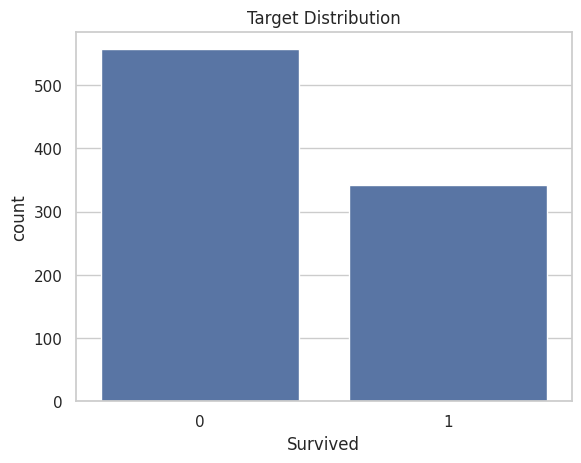

In [14]:
sns.countplot(x=df["Survived"])
plt.title("Target Distribution")
plt.show()

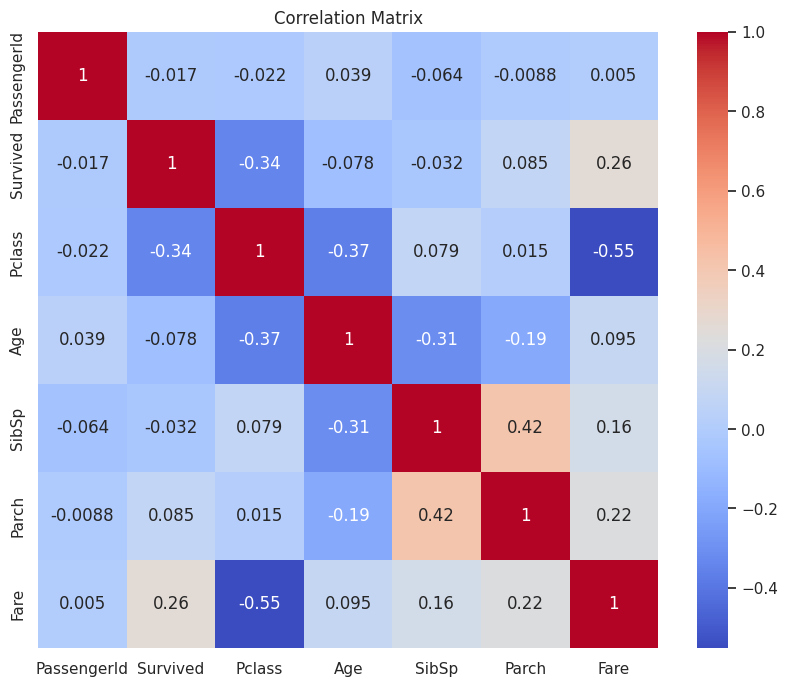

In [15]:
plt.figure(figsize=(10,8))
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [16]:
df.skew(numeric_only=True)

PassengerId   -0.000893
Survived       0.493428
Pclass        -0.644706
Age            0.385846
SibSp          3.712490
Parch          2.764894
Fare           4.805305
dtype: float64

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [3]:
df2 = pd.read_csv("../data/processed/final.csv")

print("Shape:", df2.shape)
df2.head()

Shape: (561, 8)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,3,female,26.0,0,0,7.9250,S
2,1,1,female,35.0,1,0,53.1000,S
3,0,3,male,35.0,0,0,8.0500,S
4,0,3,male,28.0,0,0,8.4583,Q


In [4]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 561 entries, 0 to 560
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  561 non-null    int64  
 1   Pclass    561 non-null    int64  
 2   Sex       561 non-null    object 
 3   Age       561 non-null    float64
 4   SibSp     561 non-null    int64  
 5   Parch     561 non-null    int64  
 6   Fare      561 non-null    float64
 7   Embarked  561 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 35.2+ KB


In [5]:
df2.describe()


,Survived,Pclass,Age,SibSp,Parch,Fare
count,561.000000,561.000000,561.000000,561.000000,561.0,561.000000
mean,0.286988,2.520499,29.171123,0.190731,0.0,13.727918
std,0.452759,0.717155,8.463058,0.440357,0.0,10.560514
min,0.000000,1.000000,5.000000,0.000000,0.0,0.000000
25%,0.000000,2.000000,24.000000,0.000000,0.0,7.775000
50%,0.000000,3.000000,28.000000,0.000000,0.0,8.458300
75%,1.000000,3.000000,32.000000,0.000000,0.0,15.050000
max,1.000000,3.000000,54.000000,2.000000,0.0,53.100000


In [6]:
df2.isna().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [7]:
df2.isna().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

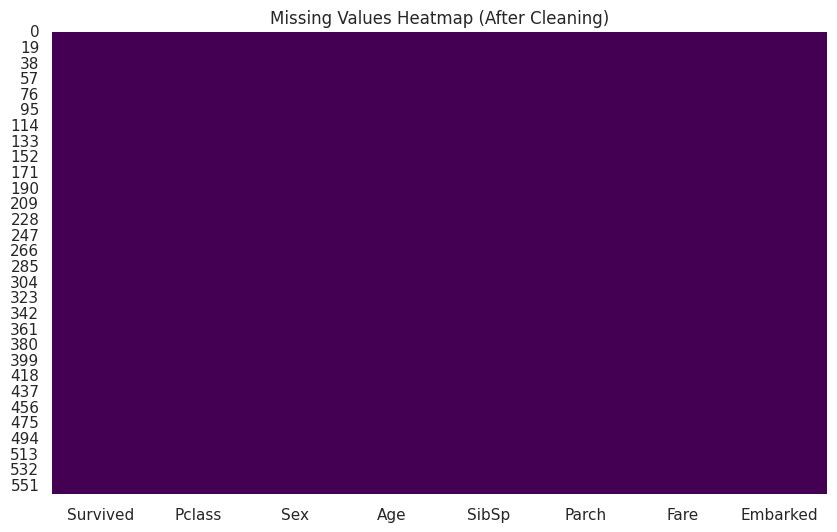

In [8]:
plt.figure(figsize=(10,6))
sns.heatmap(df2.isna(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap (After Cleaning)")
plt.show()

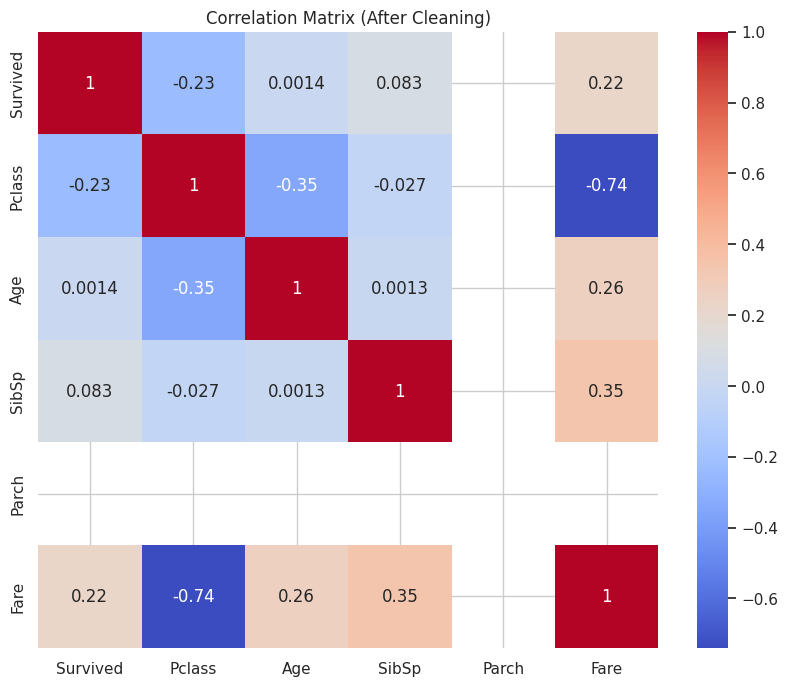

In [9]:
plt.figure(figsize=(10,8))

corr = df2.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix (After Cleaning)")
plt.show()

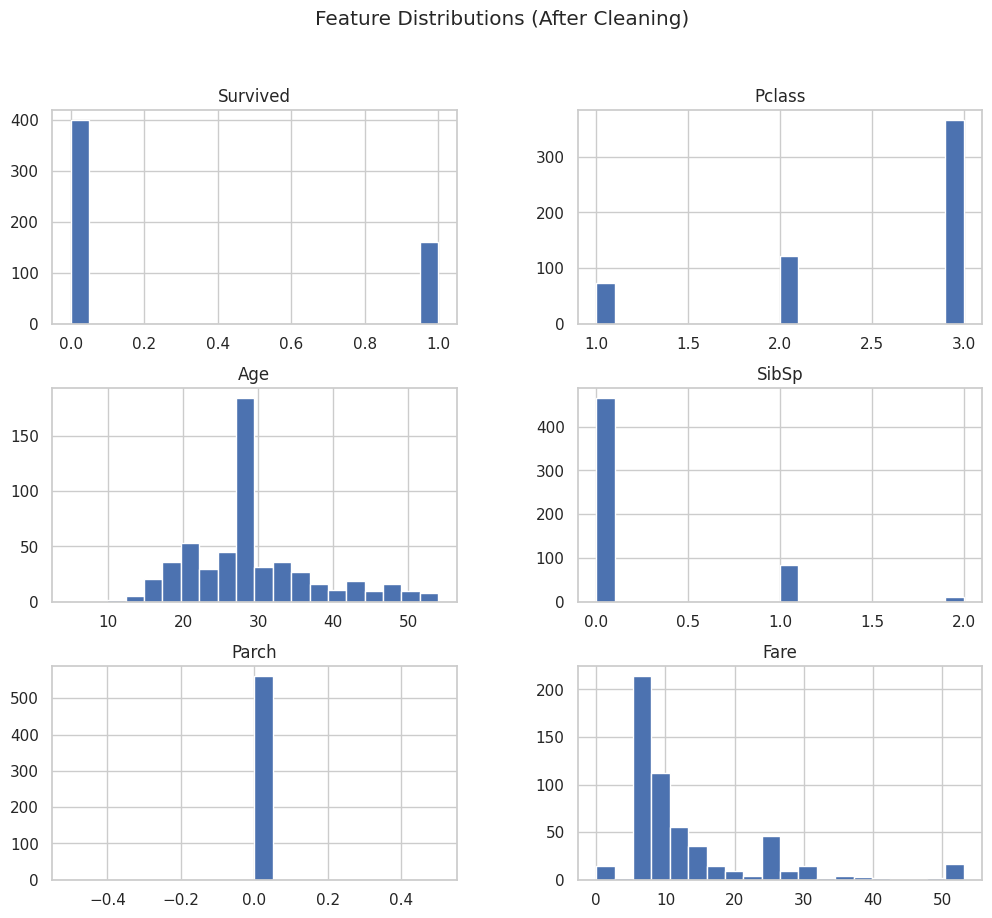

In [10]:
df2.hist(figsize=(12,10), bins=20)
plt.suptitle("Feature Distributions (After Cleaning)")
plt.show()

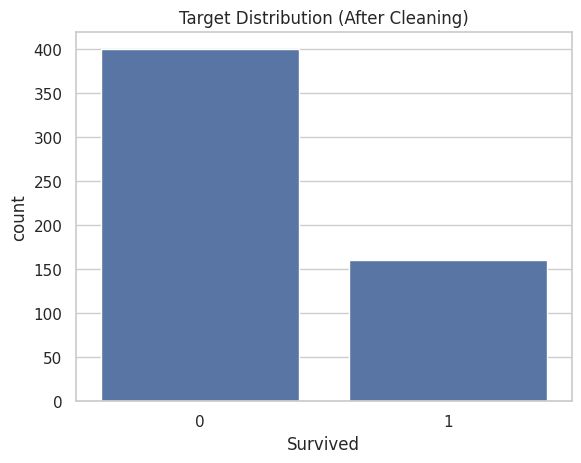

In [11]:
sns.countplot(x=df2["Survived"])
plt.title("Target Distribution (After Cleaning)")
plt.show()

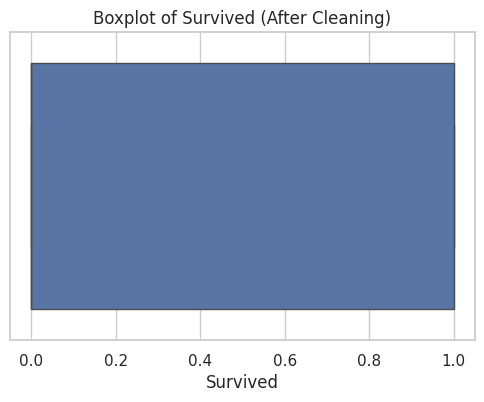

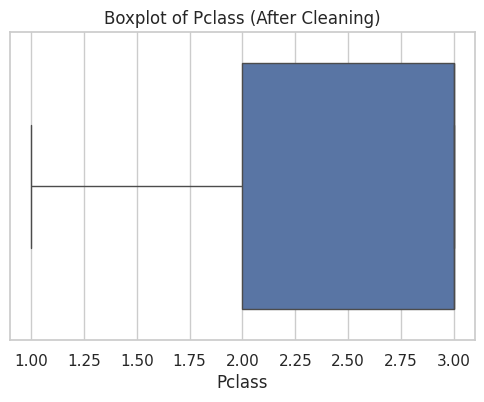

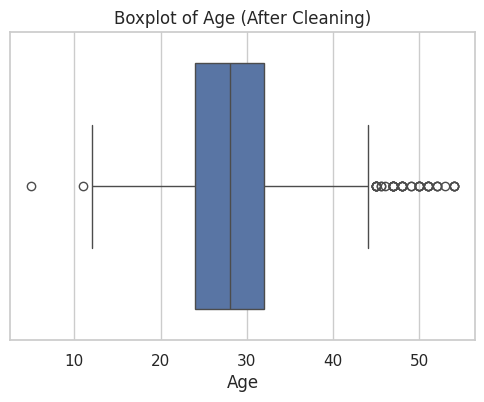

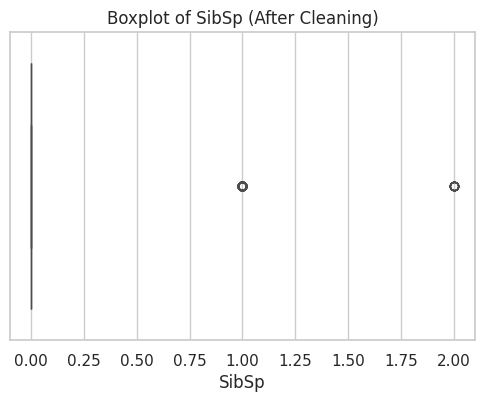

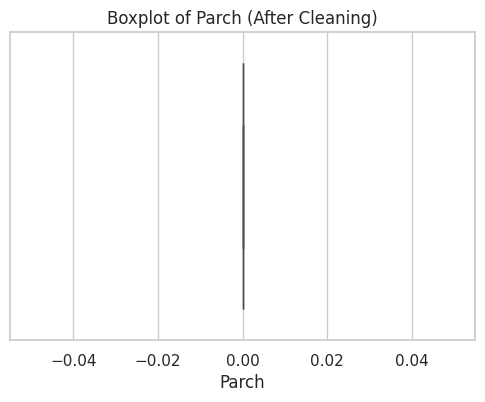

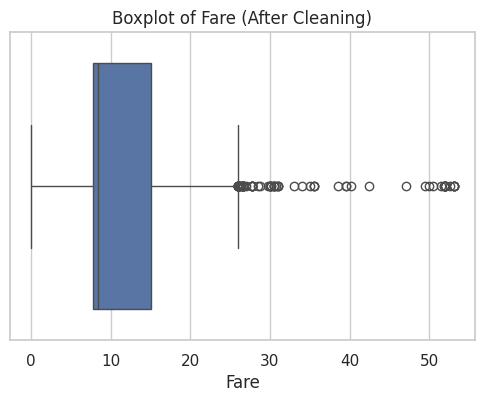

In [16]:
num_cols = df2.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df2[col])
    plt.title(f"Boxplot of {col} (After Cleaning)")
    plt.show()